**INFO 523 Data Mining and Discovery Final Project**


**Analysis of Emotions Using Keystroke Dynamics and Typing Behaviors**


This research investigates a unique keystroke dynamics dataset, depicting natural emotional experiences in the realm of human-computer interactions, and psychological research. Therefore, this research uses data taken from a comprehensive EmoS (Emotion Survey) dataset that detailed much information about participants, considering their emotional states and demographics, and their characteristics for typing behavior.

EmoSurv is a dataset containing keystroke data along with emotion labels. Timing and frequency data is recorded while participants are typing free and fixed texts before and after being induced specific emotions. These emotions are: Anger, Happiness, Calmness, Sadness, and Neutral state.

#1st question



**Question 1: What emotional characteristics are predominantly exhibited by participants who provide correct responses?**

In [1]:
# Importing libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#loading the dataset
free_text_df = pd.read_csv("Free Text Typing Dataset.csv", sep=";",on_bad_lines='skip')

In [3]:
#renaming the column names
free_text_df = free_text_df.rename(columns={
    "_id": "id",
    "userid": "User_ID",
    "emotionIndex": "emotionIndex",
    "keyCode": "keyCode",
    "keyDown": "keyDown",
    "keyUp": "keyUp",
    "D1U1": "D1U1",
    "D1U2": "D1U2",
    "D1D2": "D1D2",
    "U1D2": "U1D2",
    "U1U2": "U1U2",
    "D1U3": "D1U3",
    "D1D3": "D1D3",
    "answer": "answer"

})

In [4]:
# Filtering rows with the answer
correct_answers = free_text_df[free_text_df['answer'] == 'R']

In [5]:
print(free_text_df['answer'].unique())


[nan 'R' 'W']


In [6]:
# Dropping rows with missing 'emotionIndex' to avoid NaN issues
unique_emotions = free_text_df['emotionIndex'].dropna().unique()

# Displaying the unique emotions and their count
print("Unique Emotions:", unique_emotions)
print("Number of Unique Emotions:", len(unique_emotions))


Unique Emotions: ['N' 'H' 'C' 'A' 'S']
Number of Unique Emotions: 5


In [7]:

# Drop rows with missing two values
filtered_df = free_text_df.dropna(subset=['emotionIndex', 'answer'])

# Group by those two values
emotion_answer_counts = filtered_df.groupby(['emotionIndex', 'answer']).size().unstack(fill_value=0)


In [8]:

# Display the table
print("Answer Types for Different Emotions:")
print(emotion_answer_counts)

Answer Types for Different Emotions:
answer           R    W
emotionIndex           
H             3700  165
S             3748   47


Emotion Frequencies for Correct Answers:
 emotionIndex
S    3748
H    3700
Name: count, dtype: int64


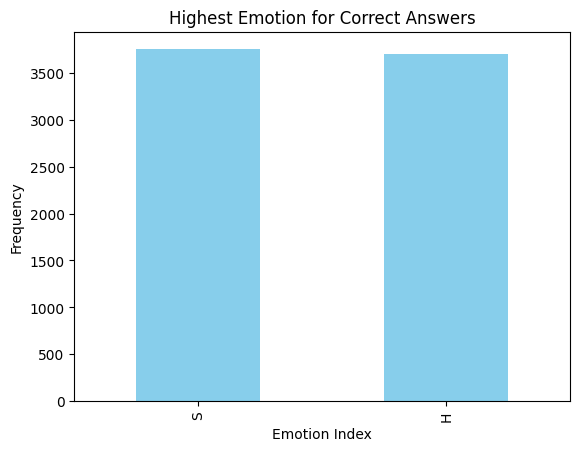

In [9]:
# Check if there are rows with correct answers
if not correct_answers.empty:
    emotion_counts = correct_answers['emotionIndex'].value_counts()
    print("Emotion Frequencies for Correct Answers:\n", emotion_counts)

    # Plot the results
    emotion_counts.plot(kind='bar', color='skyblue')
    plt.title("Highest Emotion for Correct Answers")
    plt.xlabel("Emotion Index")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("No correct answers ('R') found in the dataset.")


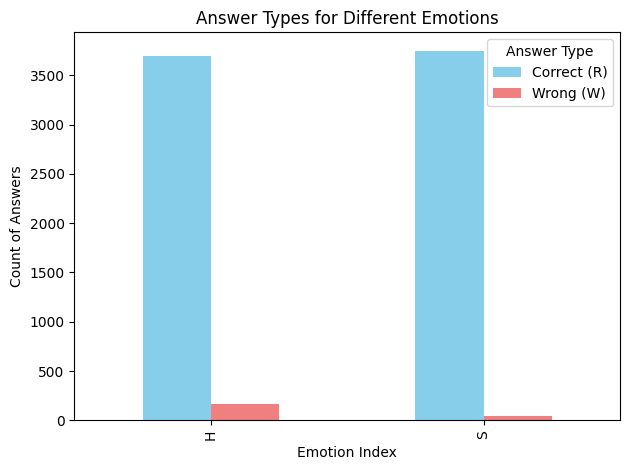

In [10]:

# Plotting the results as a bar chart
emotion_answer_counts.plot(kind='bar', stacked=False, color=['skyblue', 'lightcoral'])
plt.title("Answer Types for Different Emotions")
plt.xlabel("Emotion Index")
plt.ylabel("Count of Answers")
plt.legend(title="Answer Type", labels=["Correct (R)", "Wrong (W)"])
plt.tight_layout()
plt.show()


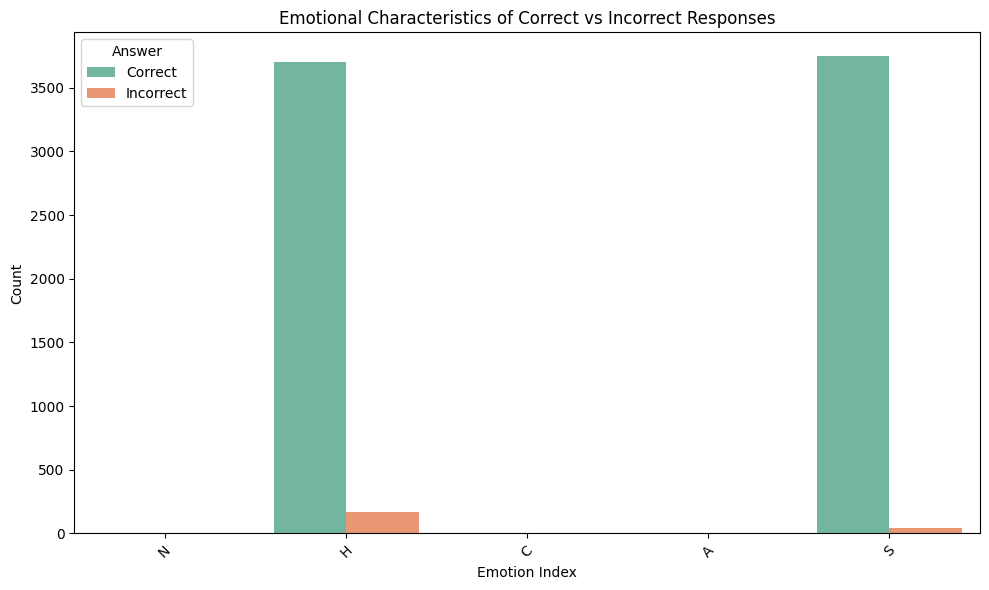

In [11]:
# Counting the number of occurrences of each emotionIndex for correct vs. incorrect answers
plt.figure(figsize=(10, 6))

sns.countplot(x='emotionIndex', hue='answer', data=free_text_df, palette='Set2')

# Adding labels and title
plt.title('Emotional Characteristics of Correct vs Incorrect Responses')
plt.xlabel('Emotion Index')
plt.ylabel('Count')
plt.legend(title='Answer', labels=[ 'Correct','Incorrect'])
plt.xticks(rotation=45)


plt.tight_layout()
plt.show()


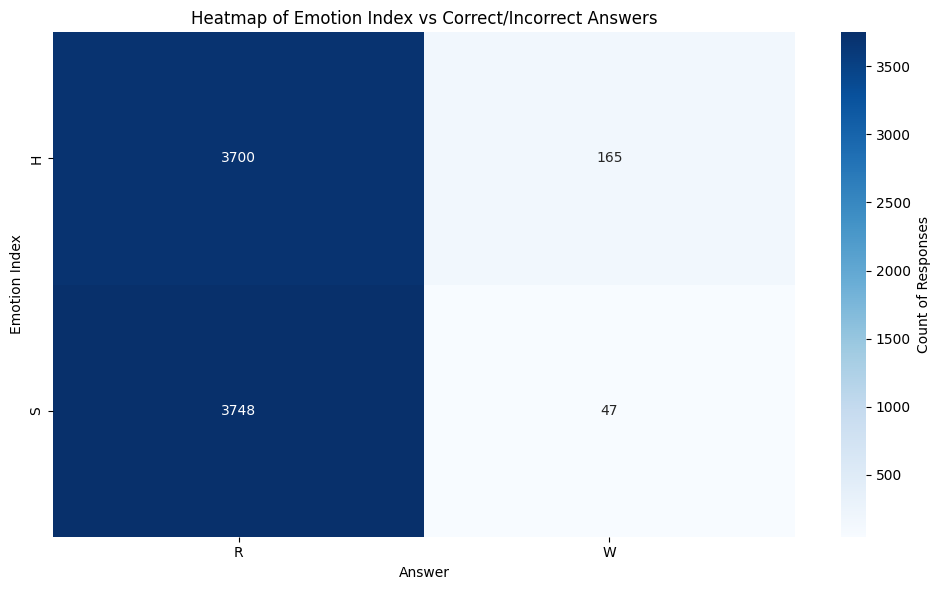

In [12]:
# Creating a pivot table for emotionIndex vs answer
emotion_answer_pivot = free_text_df.groupby(['emotionIndex', 'answer']).size().unstack(fill_value=0)

# Plotting a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(emotion_answer_pivot, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count of Responses'})

# Adding title and labels
plt.title('Heatmap of Emotion Index vs Correct/Incorrect Answers')
plt.xlabel('Answer')
plt.ylabel('Emotion Index')

# Showing the plot
plt.tight_layout()
plt.show()


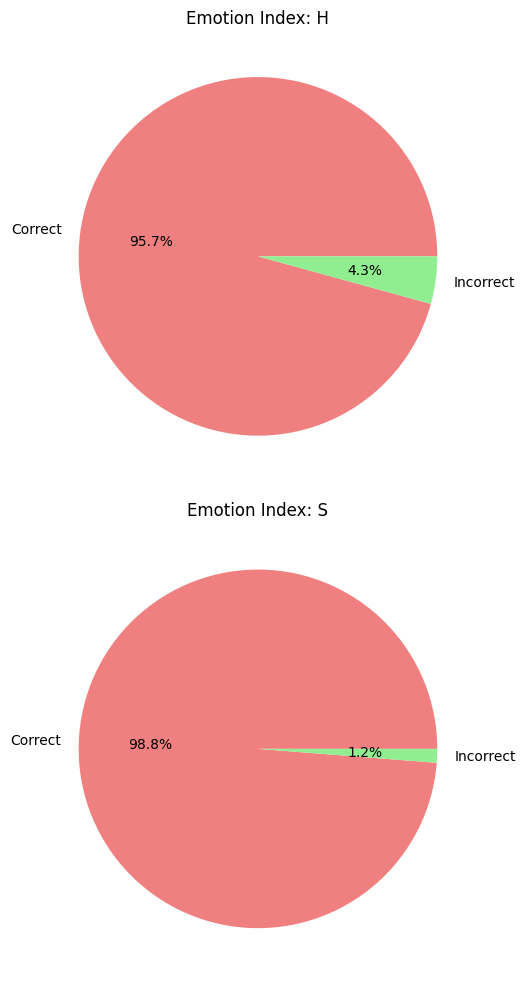

In [13]:
# Plotting pie charts for each emotionIndex's distribution of correct vs incorrect answers
emotion_answer_counts = free_text_df.groupby(['emotionIndex', 'answer']).size().unstack(fill_value=0)

# Creating a subplot for each emotionIndex
fig, axes = plt.subplots(len(emotion_answer_counts), 1, figsize=(10, len(emotion_answer_counts) * 5))
fig.tight_layout()

for i, emotion in enumerate(emotion_answer_counts.index):
    axes[i].pie(emotion_answer_counts.loc[emotion], labels=['Correct','Incorrect'], autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
    axes[i].set_title(f'Emotion Index: {emotion}')

plt.show()


#2nd question

**Question 2: How do emotional states (emotionIndex) vary across different age ranges?**

In [14]:
# Importing libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder



In [15]:
participants = pd.read_csv("/content/Participants Information.csv", sep=";")

In [16]:
#renaming columns
participants = participants.rename(columns={
    "userId": "User_ID",
    "typeWith": "typeWith",
    "typistType": "typistType",
    "pcTimeAverage": "pcTimeAverage",
    "ageRange": "ageRange",
    "gender": "gender",
    "status": "status",
    "degree": "degree",
    "country": "country"

})

In [17]:
frequency_df = pd.read_csv("Frequency Dataset.csv", sep=";")

In [18]:
#renaming columns
frequency_df = frequency_df.rename(columns={
    "User ID": "User_ID",
    "textIndex": "textIndex",
    "emotionIndex": "emotionIndex",
    "delFreq": "delFreq",
    "leftFreq": "leftFreq",
    "TotTime": "TotTime"
})

In [19]:
import pandas as pd

# Merging the two datasets on 'User_ID'
merged_df = pd.merge(frequency_df, participants, on='User_ID', how='inner')  # Change 'how' based on the type of merge

print(merged_df.head())


   User_ID textIndex emotionIndex  delFreq  leftFreq   TotTime typeWith  \
0      100        FI            N        8         1  192762.0  2 hands   
1      100        FI            N        8         1  192762.0  2 hands   
2      100        FI            N        8         1  192762.0  2 hands   
3      100        FR            N      145         0       NaN  2 hands   
4      100        FR            N      145         0       NaN  2 hands   

     typistType                       pcTimeAverage ageRange  gender   status  \
0  Touch Typist           More than 3 hours per day    16-19  Female  Student   
1  Touch Typist  between 1 hour and 3 hours per day    20-29    Male  Student   
2  Touch Typist           More than 3 hours per day    20-29  Female  Student   
3  Touch Typist           More than 3 hours per day    16-19  Female  Student   
4  Touch Typist  between 1 hour and 3 hours per day    20-29    Male  Student   

               degree  country  
0  College/University  Tunisi

In [20]:
# Calculate descriptive statistics for 'emotionIndex' by 'ageRange'
age_emotion_stats = merged_df.groupby('ageRange')['emotionIndex'].describe()
print(age_emotion_stats)

         count unique top freq
ageRange                      
16-19       36      5   N   18
20-29      723      5   N  353
30-39       75      5   N   41
>=50        14      3   N    8


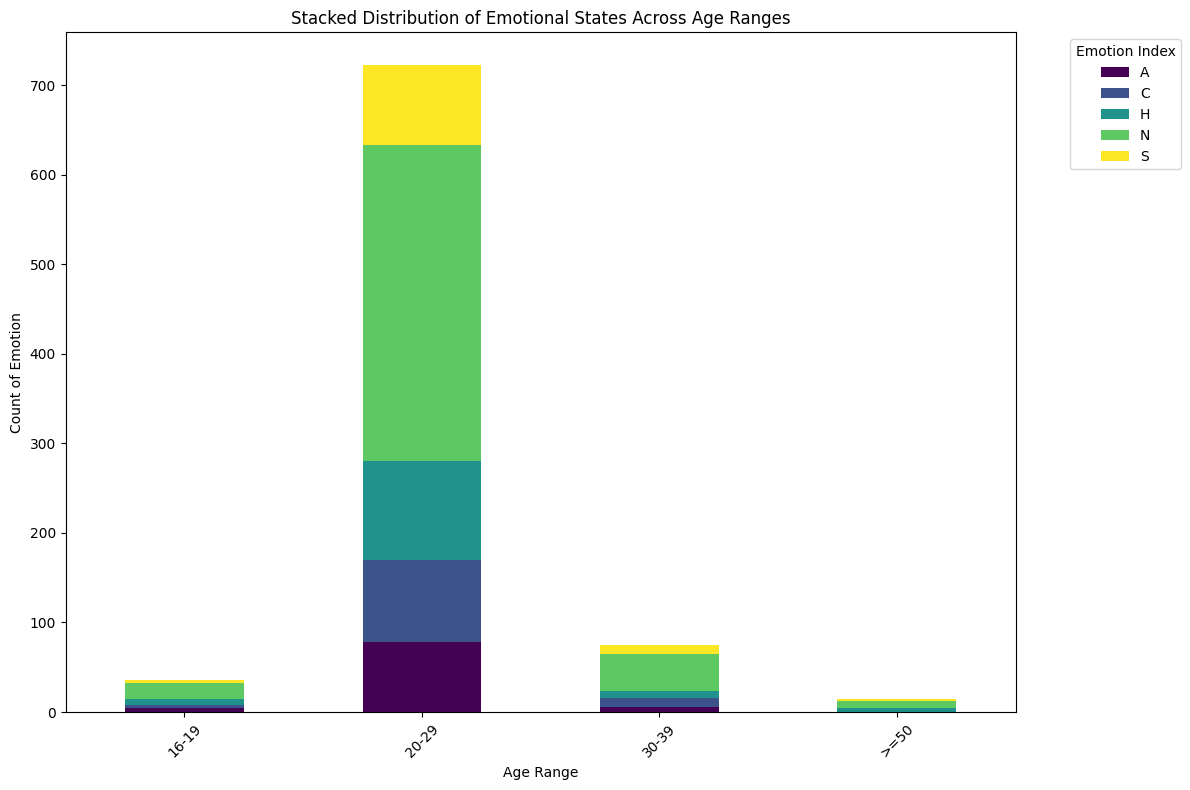

In [21]:

import seaborn as sns



# Group by 'ageRange' and 'emotionIndex' and count occurrences
emotion_count = merged_df.groupby(['ageRange', 'emotionIndex']).size().unstack(fill_value=0)

# Plotting the stacked bar chart
emotion_count.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='viridis')

# Customizing the plot for better readability
plt.title('Stacked Distribution of Emotional States Across Age Ranges')
plt.xlabel('Age Range')
plt.ylabel('Count of Emotion')
plt.xticks(rotation=45)
plt.legend(title='Emotion Index', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Showing the plot
plt.show()


<Figure size 1000x600 with 0 Axes>

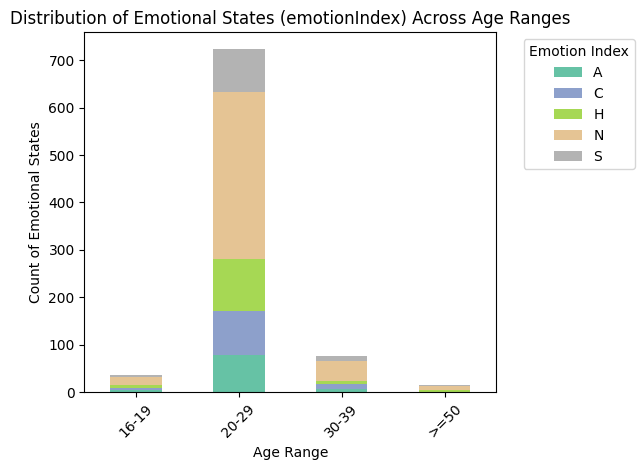

In [22]:
# Grouping the data by 'ageRange' and 'emotionIndex', then count occurrences
emotion_distribution = merged_df.groupby(['ageRange', 'emotionIndex']).size().unstack(fill_value=0)

# Plotting the stacked bar plot
plt.figure(figsize=(10, 6))
emotion_distribution.plot(kind='bar', stacked=True, colormap='Set2')

# Adding labels and title
plt.title('Distribution of Emotional States (emotionIndex) Across Age Ranges')
plt.xlabel('Age Range')
plt.ylabel('Count of Emotional States')
plt.xticks(rotation=45)
plt.legend(title='Emotion Index', bbox_to_anchor=(1.05, 1), loc='upper left')

# Showing the plot
plt.tight_layout()
plt.show()


<ipython-input-23-4bbab1a1460d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ageRange', y='emotionIndex', data=merged_df, palette='Blues')


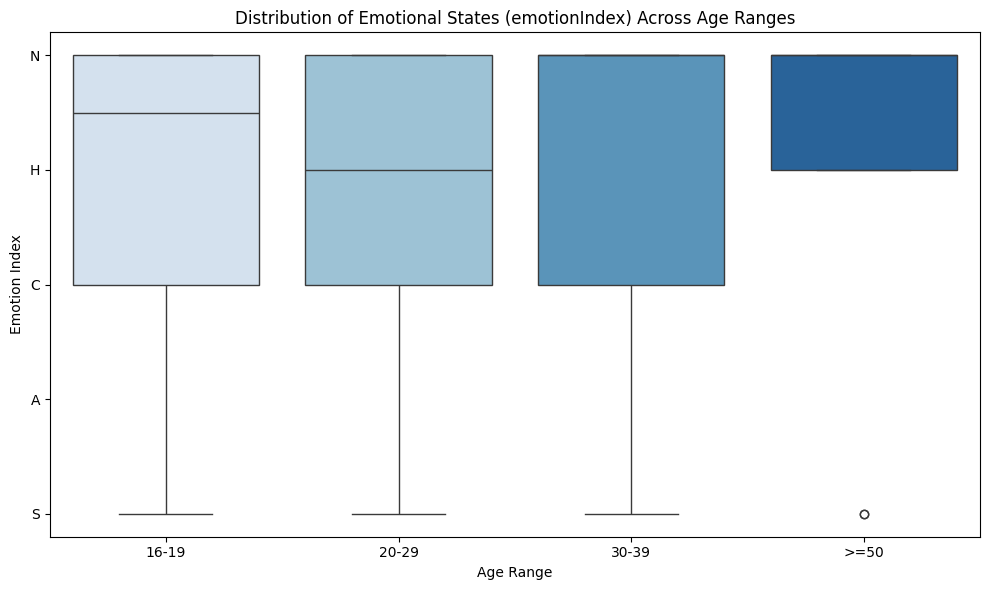

In [23]:
# Boxplot for emotionIndex across different ageRanges
plt.figure(figsize=(10, 6))
sns.boxplot(x='ageRange', y='emotionIndex', data=merged_df, palette='Blues')

# Adding labels and title
plt.title('Distribution of Emotional States (emotionIndex) Across Age Ranges')
plt.xlabel('Age Range')
plt.ylabel('Emotion Index')

# Showing the plot
plt.tight_layout()
plt.show()


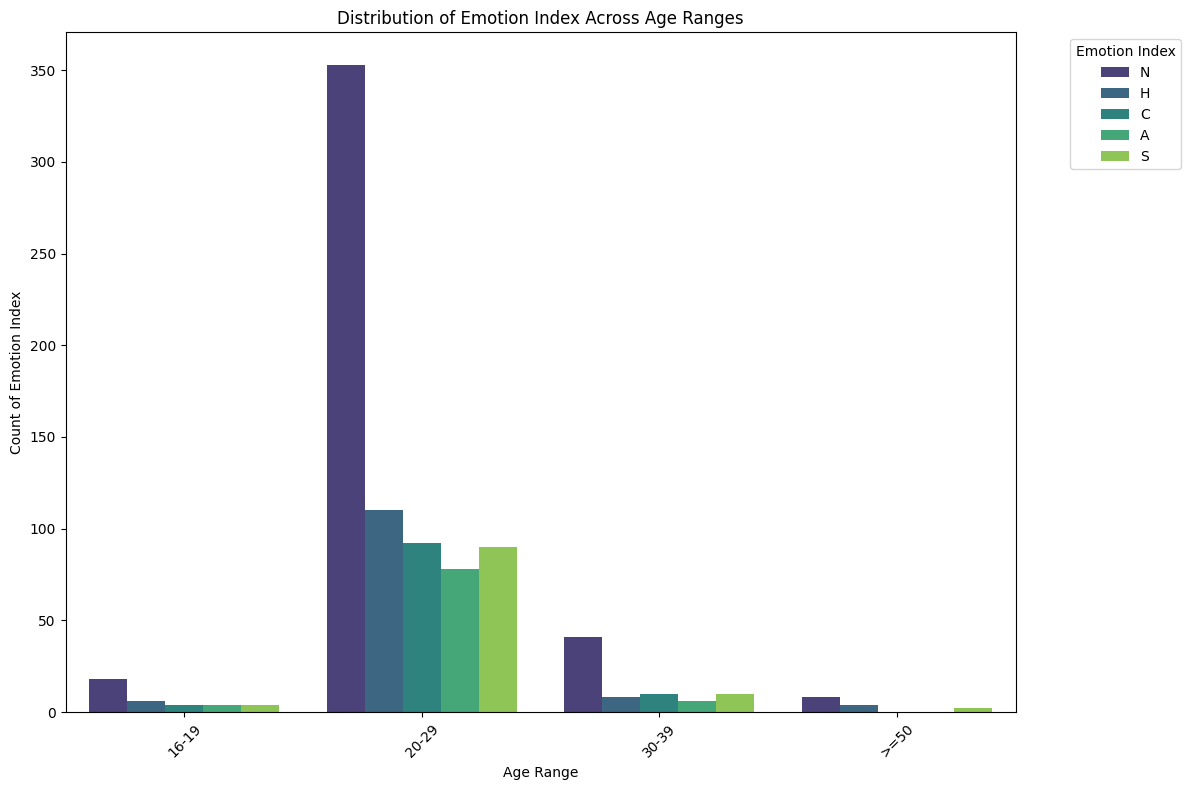

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the count plot for emotionIndex across ageRange
plt.figure(figsize=(12, 8))
sns.countplot(x='ageRange', hue='emotionIndex', data=merged_df, palette='viridis')
plt.title('Distribution of Emotion Index Across Age Ranges')
plt.xlabel('Age Range')
plt.ylabel('Count of Emotion Index')
plt.xticks(rotation=45)
plt.legend(title='Emotion Index', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#3rd question

**What is the relationship between typing speed (key press frequency) and emotion index?**


In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [92]:
frequency_df = pd.read_csv("Frequency Dataset.csv", sep=";")
frequency_df

,User ID,textIndex,emotionIndex,delFreq,leftFreq,TotTime
0,100,FI,N,8,1,192762.0
1,100,FR,N,145,0,NaN
2,100,FR,H,0,0,NaN
3,100,FI,H,11,0,99463.0
4,113,FI,N,10,0,84265.0
...,...,...,...,...,...,...
473,41,FI,C,1,0,59135.0
474,72,FI,N,6,0,67789.0
475,72,FR,N,4,0,NaN
476,113,FI,N,9,0,37576.0


In [93]:
# Cleaning the data
filtered_df = frequency_df.dropna(subset=['delFreq', 'leftFreq', 'emotionIndex'])


In [94]:
# Convert emotionIndex to numeric
filtered_df['emotionIndex_numeric'] = pd.to_numeric(filtered_df['emotionIndex'], errors='coerce')


In [95]:


# Check if there are still NaN values in emotionIndex_numeric
print(filtered_df['emotionIndex_numeric'].isnull().sum(), "rows have invalid emotionIndex values.")


478 rows have invalid emotionIndex values.


In [96]:

# Calculating the correlation
correlation_delfreq = filtered_df[['delFreq', 'emotionIndex_numeric']].corr()
correlation_leftfreq = filtered_df[['leftFreq', 'emotionIndex_numeric']].corr()


In [97]:

# Print correlation values
print("Correlation between DelFreq and emotionIndex:", correlation_delfreq)
print("Correlation between LeftFreq and emotionIndex:", correlation_leftfreq)


Correlation between DelFreq and emotionIndex:                       delFreq  emotionIndex_numeric
delFreq                   1.0                   NaN
emotionIndex_numeric      NaN                   NaN
Correlation between LeftFreq and emotionIndex:                       leftFreq  emotionIndex_numeric
leftFreq                   1.0                   NaN
emotionIndex_numeric       NaN                   NaN


In [98]:
frequency_df['emotionIndex'].unique()

array(['N', 'H', 'C', 'A', 'S'], dtype=object)

In [99]:
# Create a mapping for emotionIndex to numeric values
emotion_mapping = {
    'N': 0,  # Neutral
    'H': 1,  # Happy
    'C': 2,  # Confused
    'A': 3,  # Angry
    'S': 4   # Sad
}

# Apply the mapping to emotionIndex
frequency_df['emotionIndex_numeric'] = frequency_df['emotionIndex'].map(emotion_mapping)

# Check for any rows that were not mapped correctly
print(frequency_df['emotionIndex_numeric'].isnull().sum(), "rows have unrecognized emotionIndex values.")


0 rows have unrecognized emotionIndex values.


In [100]:
# Drop rows with missing values
filtered_frequency_df = frequency_df.dropna(subset=['delFreq', 'leftFreq', 'emotionIndex_numeric'])


In [101]:

# Calculate the correlation
correlation_delfreq = filtered_frequency_df[['delFreq', 'emotionIndex_numeric']].corr()

# Calculate the correlation
correlation_leftfreq = filtered_frequency_df[['leftFreq', 'emotionIndex_numeric']].corr()

# Print the correlation
print("Correlation between DelFreq and emotionIndex:", correlation_delfreq)



Correlation between DelFreq and emotionIndex:                        delFreq  emotionIndex_numeric
delFreq               1.000000             -0.139627
emotionIndex_numeric -0.139627              1.000000


In [102]:
print("Correlation between LeftFreq and emotionIndex:", correlation_leftfreq)

Correlation between LeftFreq and emotionIndex:                       leftFreq  emotionIndex_numeric
leftFreq              1.000000             -0.102251
emotionIndex_numeric -0.102251              1.000000


In [103]:
# Inspect unique values in emotionIndex
invalid_values = frequency_df['emotionIndex'].unique()
print("Unique values in emotionIndex:", invalid_values)

Unique values in emotionIndex: ['N' 'H' 'C' 'A' 'S']


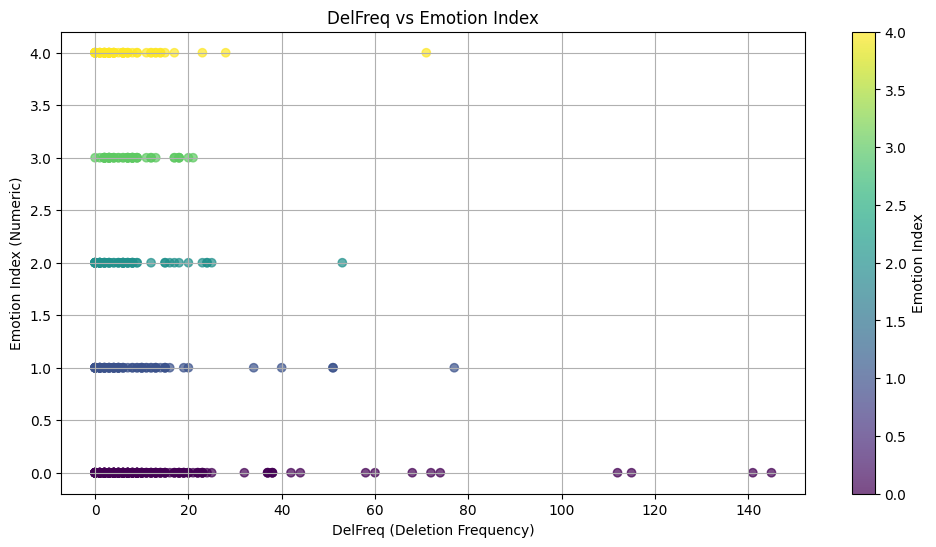

In [104]:
import matplotlib.pyplot as plt

# Scatter plot for DelFreq vs emotionIndex
plt.figure(figsize=(12, 6))
plt.scatter(filtered_frequency_df['delFreq'], filtered_frequency_df['emotionIndex_numeric'],
            c=filtered_frequency_df['emotionIndex_numeric'], cmap='viridis', alpha=0.7)
plt.title('DelFreq vs Emotion Index')
plt.xlabel('DelFreq (Deletion Frequency)')
plt.ylabel('Emotion Index (Numeric)')
plt.colorbar(label='Emotion Index')
plt.grid(True)
plt.show()



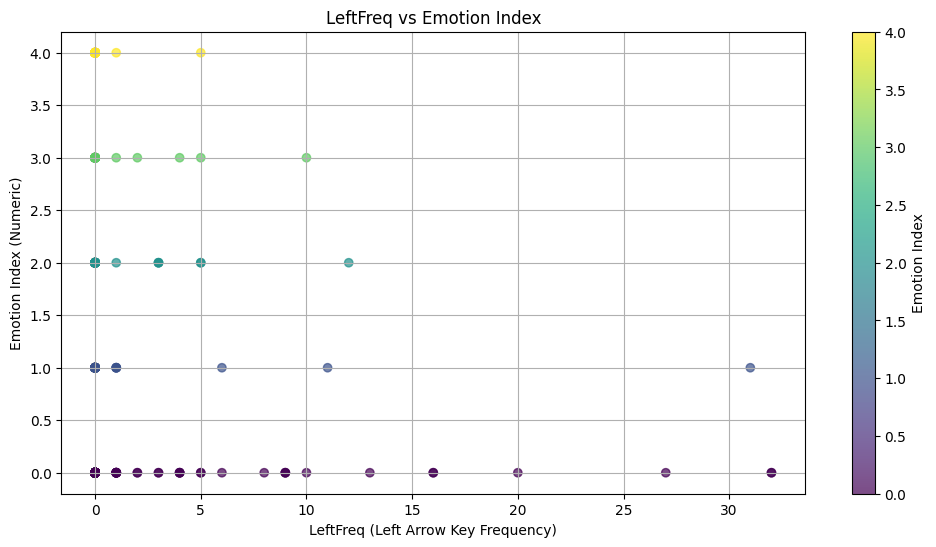

In [105]:

# Scatter plot for LeftFreq vs emotionIndex
plt.figure(figsize=(12, 6))
plt.scatter(filtered_frequency_df['leftFreq'], filtered_frequency_df['emotionIndex_numeric'], c=filtered_frequency_df['emotionIndex_numeric'], cmap='viridis', alpha=0.7)
plt.title('LeftFreq vs Emotion Index')
plt.xlabel('LeftFreq (Left Arrow Key Frequency)')
plt.ylabel('Emotion Index (Numeric)')
plt.colorbar(label='Emotion Index')
plt.grid(True)
plt.show()

<ipython-input-106-df349e66ce6e>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_frequency_df, x='emotionIndex', y='delFreq', palette='Set2')


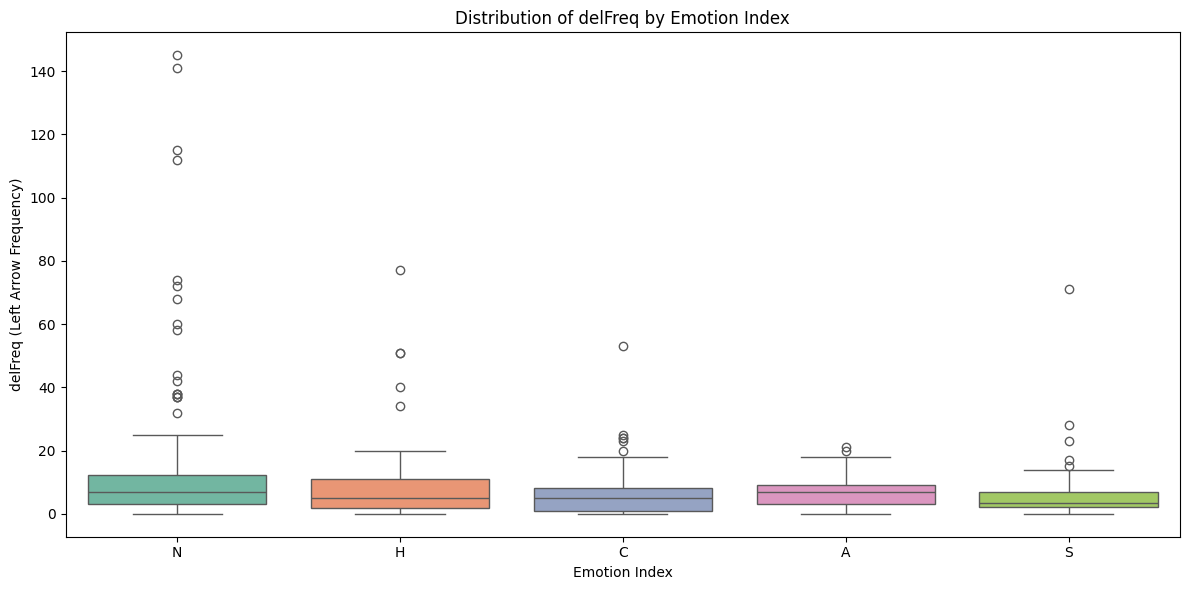

In [106]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=filtered_frequency_df, x='emotionIndex', y='delFreq', palette='Set2')
plt.title('Distribution of delFreq by Emotion Index')
plt.xlabel('Emotion Index')
plt.ylabel('delFreq (Left Arrow Frequency)')
plt.tight_layout()
plt.show()

<ipython-input-107-2338b2298b46>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_frequency_df, x='emotionIndex', y='leftFreq', palette='Set2')


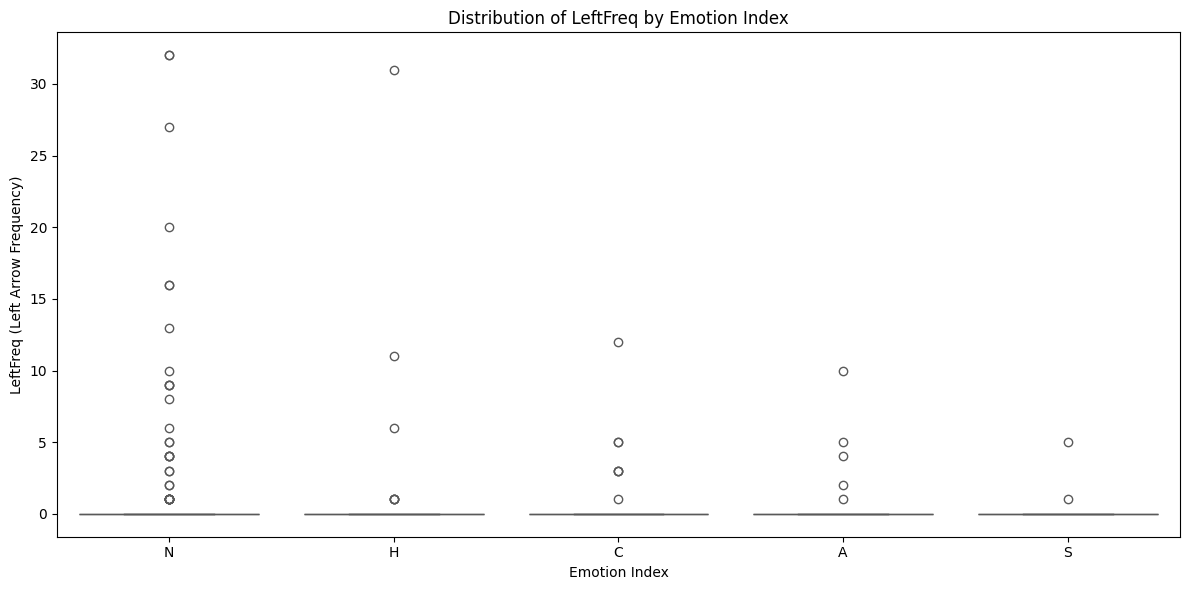

In [107]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=filtered_frequency_df, x='emotionIndex', y='leftFreq', palette='Set2')
plt.title('Distribution of LeftFreq by Emotion Index')
plt.xlabel('Emotion Index')
plt.ylabel('LeftFreq (Left Arrow Frequency)')
plt.tight_layout()
plt.show()

<ipython-input-109-a7e91901b039>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='ageRange', y='TotTime', palette='Set3')


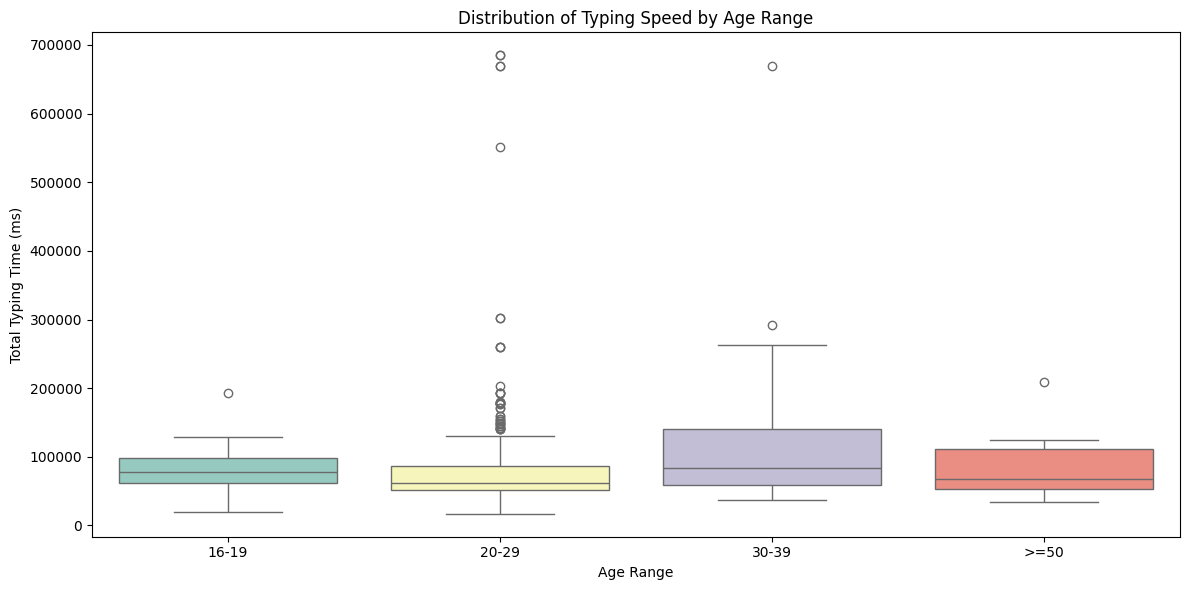

In [109]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=merged_df, x='ageRange', y='TotTime', palette='Set3')
plt.title('Distribution of Typing Speed by Age Range')
plt.xlabel('Age Range')
plt.ylabel('Total Typing Time (ms)')
plt.tight_layout()
plt.show()


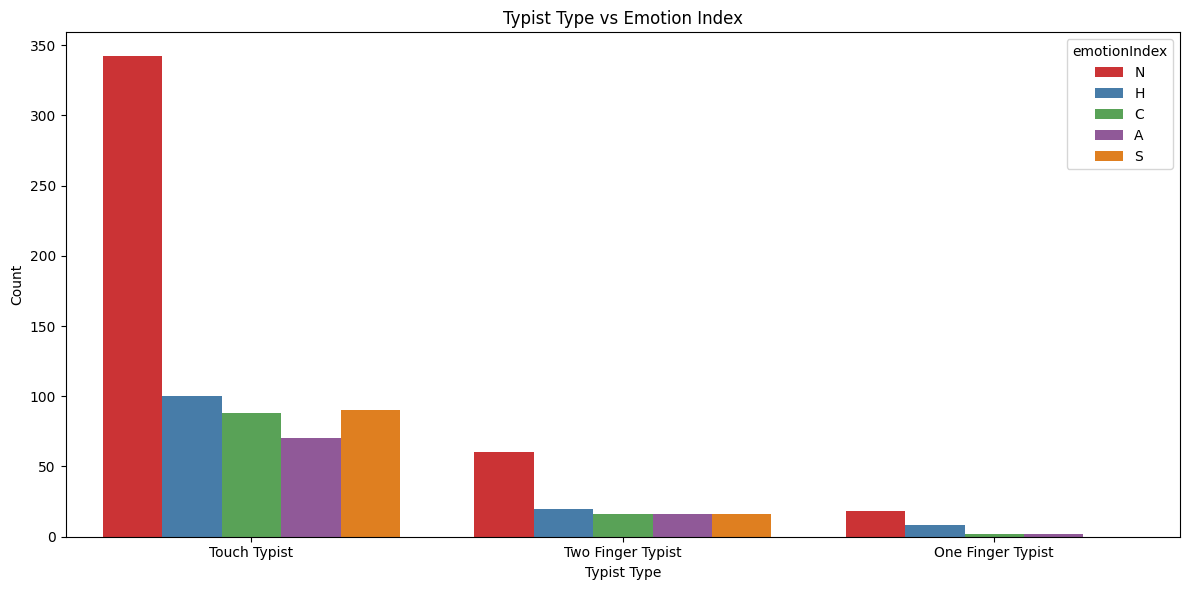

In [110]:
#plot which says about typist type vs emotion Index
plt.figure(figsize=(12, 6))
sns.countplot(data=merged_df, x='typistType', hue='emotionIndex', palette='Set1')
plt.title('Typist Type vs Emotion Index')
plt.xlabel('Typist Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


#KNN

In [17]:
# Importing necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

In [18]:
# Load the dataset
frequency_df = pd.read_csv("Frequency Dataset.csv", sep=";")


In [19]:
# Check for any missing values in the dataset
print(frequency_df.isnull().sum())


User ID           0
textIndex         0
emotionIndex      0
delFreq           0
leftFreq          0
TotTime         235
dtype: int64


In [20]:
#filling the missing values with mean
frequency_df['TotTime'] = frequency_df['TotTime'].fillna(frequency_df['TotTime'].mean())


In [21]:
print(frequency_df.isnull().sum())

User ID         0
textIndex       0
emotionIndex    0
delFreq         0
leftFreq        0
TotTime         0
dtype: int64


In [22]:
features = ['User ID', 'textIndex', 'delFreq', 'leftFreq', 'TotTime']
 # Emotion index is the target variable
target = 'emotionIndex'


In [23]:
# We'll drop 'User ID' since it's an identifier, not a feature for prediction
X = frequency_df[features].drop('User ID', axis=1)
y = frequency_df[target]


In [24]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Check the type of the 'textIndex' column
print(frequency_df['textIndex'].dtype)


object


In [26]:

# as 'textIndex' is categorical, applying Label Encoding
label_encoder = LabelEncoder()


In [27]:

# Applying label encoding to 'textIndex'
if frequency_df['textIndex'].dtype == 'object':  # checking if it's non-numeric
    frequency_df['textIndex'] = label_encoder.fit_transform(frequency_df['textIndex'])


In [28]:

# Now 'textIndex' should be numeric and can be scaled
X = frequency_df[['textIndex', 'delFreq', 'leftFreq', 'TotTime']]  # Example feature set
y = frequency_df['emotionIndex']  # Target column


In [29]:

# Split the data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [30]:
# Feature Scaling (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [31]:
#Apply KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can experiment with different k values
knn.fit(X_train_scaled, y_train)


KNeighborsClassifier()

In [32]:
# Predict and Evaluate the Model
y_pred = knn.predict(X_test_scaled)


In [33]:
# Evaluate the model
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')


Accuracy: 0.3854


In [34]:
print('Classification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           A       0.09      0.33      0.14         6
           C       0.00      0.00      0.00        16
           H       0.44      0.31      0.36        13
           N       0.57      0.57      0.57        51
           S       0.18      0.20      0.19        10

    accuracy                           0.39        96
   macro avg       0.26      0.28      0.25        96
weighted avg       0.39      0.39      0.38        96



In [35]:
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[ 2  0  0  3  1]
 [ 4  0  1 10  1]
 [ 1  0  4  7  1]
 [12  3  1 29  6]
 [ 3  0  3  2  2]]


In [36]:
# Hyperparameter Tuning (finding the best 'k' value)
k_range = range(1, 21)  # Example k values from 1 to 20
accuracies = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(knn.score(X_test_scaled, y_test))


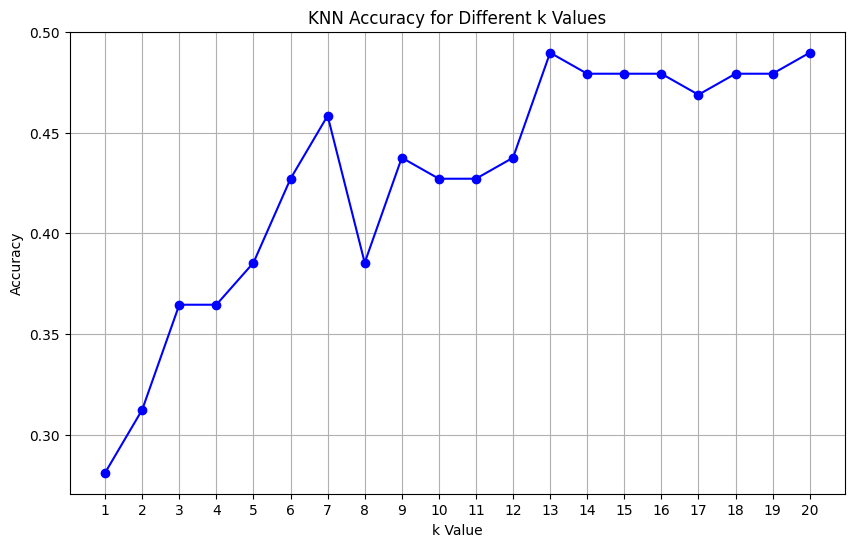

In [37]:
# Plotting the results of different 'k' values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='-', color='b')
plt.title('KNN Accuracy for Different k Values')
plt.xlabel('k Value')
plt.ylabel('Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.show()


#XGBOOST

In [38]:
# Import necessary libraries
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [39]:
# Preprocessing the Data
# Load the dataset (if not already loaded)
frequency_df = pd.read_csv("Frequency Dataset.csv", sep=";")


In [67]:
frequency_df

,User ID,textIndex,emotionIndex,delFreq,leftFreq,TotTime
0,100,FI,N,8,1,192762.0
1,100,FR,N,145,0,NaN
2,100,FR,H,0,0,NaN
3,100,FI,H,11,0,99463.0
4,113,FI,N,10,0,84265.0
...,...,...,...,...,...,...
473,41,FI,C,1,0,59135.0
474,72,FI,N,6,0,67789.0
475,72,FR,N,4,0,NaN
476,113,FI,N,9,0,37576.0


In [40]:
# Replacing missing values (if any)
frequency_df['TotTime'] = frequency_df['TotTime'].fillna(frequency_df['TotTime'].mean())


In [41]:

label_encoder = LabelEncoder()
frequency_df['textIndex'] = label_encoder.fit_transform(frequency_df['textIndex'])


In [42]:
target_encoder = LabelEncoder()
frequency_df['emotionIndex'] = target_encoder.fit_transform(frequency_df['emotionIndex'])


In [43]:

if frequency_df['textIndex'].dtype == 'object':
    frequency_df['textIndex'] = label_encoder.fit_transform(frequency_df['textIndex'])


In [46]:
# Defining Features and Target
features = ['textIndex', 'delFreq', 'leftFreq', 'TotTime']  # Example features
X = frequency_df[features]
y = frequency_df['emotionIndex']  # Target variable


In [48]:
#Split the Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [49]:
#Feature Scaling (important for models like KNN, but optional for XGBoost)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [50]:
model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(y.unique()), use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train_scaled, y_train)


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [16:16:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=5, num_parallel_tree=None, ...)

In [51]:
# Making Predictions on Test Data
y_pred = model.predict(X_test_scaled)


In [52]:
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.4167
Classification Report:
              precision    recall  f1-score   support

           0       0.15      0.33      0.21         6
           1       0.00      0.00      0.00        16
           2       0.30      0.23      0.26        13
           3       0.55      0.65      0.59        51
           4       0.33      0.20      0.25        10

    accuracy                           0.42        96
   macro avg       0.27      0.28      0.26        96
weighted avg       0.38      0.42      0.39        96

Confusion Matrix:
[[ 2  1  0  3  0]
 [ 2  0  2 11  1]
 [ 1  1  3  7  1]
 [ 7  4  5 33  2]
 [ 1  1  0  6  2]]


#SVM

In [53]:
# Import necessary libraries
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [54]:
#Preprocessing the Data
import pandas as pd
frequency_df = pd.read_csv("Frequency Dataset.csv", sep=";")


In [55]:
# Handling missing values (fill missing values in 'TotTime' with the mean)
frequency_df['TotTime'] = frequency_df['TotTime'].fillna(frequency_df['TotTime'].mean())


In [56]:

label_encoder = LabelEncoder()

frequency_df['textIndex'] = label_encoder.fit_transform(frequency_df['textIndex'])


In [57]:
if frequency_df['textIndex'].dtype == 'object':
    frequency_df['textIndex'] = label_encoder.fit_transform(frequency_df['textIndex'])


In [58]:
target_encoder = LabelEncoder()
frequency_df['emotionIndex'] = target_encoder.fit_transform(frequency_df['emotionIndex'])


In [59]:
features = ['textIndex', 'delFreq', 'leftFreq', 'TotTime']  # Example features
X = frequency_df[features]
y = frequency_df['emotionIndex']  # Target variable


In [61]:
#Splitting the Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [62]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [63]:
# Training the SVM Model
model = SVC(kernel='linear')  # You can also try 'rbf' or 'poly' kernels
model.fit(X_train_scaled, y_train)


SVC(kernel='linear')

In [88]:
# Making Predictions on Test Data
y_pred = model.predict(X_test_scaled)


In [89]:
# Evaluating the Model
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.5625
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.00      0.00      0.00        16
           2       1.00      0.23      0.38        13
           3       0.55      1.00      0.71        51
           4       0.00      0.00      0.00        10

    accuracy                           0.56        96
   macro avg       0.31      0.25      0.22        96
weighted avg       0.43      0.56      0.43        96

Confusion Matrix:
[[ 0  0  0  6  0]
 [ 0  0  0 16  0]
 [ 0  0  3 10  0]
 [ 0  0  0 51  0]
 [ 0  0  0 10  0]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Compared to the previous works in this area, the results we got are similar for all the models that we have performed in this project.